In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import scipy.io as sio

DATA_PATH = "/content/drive/MyDrive/replay_event/processed-rat-data/"
N_SESSIONS = 4
THRESHOLD_STD = 3

# phase mapping matches COL_PHASE from data_processing.ipynb:
# 0=other, 1=running towards port, 2=at reward port, 3=running away from port
PHASE_NAMES = {0: "other",
               1: "running towards port",
               2: "at reward port",
               3: "running away from port"}

for i in range(1, N_SESSIONS + 1):
    fname = f"spDat{i}0.mat"
    dat = sio.loadmat(f"{DATA_PATH}/{fname}")

    X = dat['X']           # (n_timesteps, n_neurons)
    lapID = dat['lapID']   # columns: trial, cv_fold, virtual_arm, orig_idx, phase
    phase_col = lapID[:, 4]

    for phase in range(4):  # now includes phase 0
        phase_mask = phase_col == phase
        X_phase = X[phase_mask]

        # population activity: sum spikes across all neurons at each timebin
        pop_activity = X_phase.sum(axis=1)  # (n_timesteps,)

        # detect bursts: timepoints where population activity > mean + threshold*std
        mean = pop_activity.mean()
        std  = pop_activity.std()
        burst_mask = pop_activity > (mean + THRESHOLD_STD * std)
        burst_idx  = np.where(burst_mask)[0]

        print(f"Session {i} phase {phase} ({PHASE_NAMES[phase]}):")
        print(f"  total timesteps: {X_phase.shape[0]}")
        print(f"  burst events detected: {len(burst_idx)}")
        print(f"  population activity mean={mean:.3f}, std={std:.3f}")
        print()

Session 1 phase 0 (other):
  total timesteps: 4621
  burst events detected: 28
  population activity mean=35.806, std=13.201

Session 1 phase 1 (running towards port):
  total timesteps: 7532
  burst events detected: 83
  population activity mean=44.305, std=7.623

Session 1 phase 2 (at reward port):
  total timesteps: 54175
  burst events detected: 1163
  population activity mean=27.418, std=15.849

Session 1 phase 3 (running away from port):
  total timesteps: 16337
  burst events detected: 56
  population activity mean=38.483, std=11.988

Session 2 phase 0 (other):
  total timesteps: 715
  burst events detected: 6
  population activity mean=12.984, std=8.935

Session 2 phase 1 (running towards port):
  total timesteps: 3980
  burst events detected: 0
  population activity mean=26.896, std=5.127

Session 2 phase 2 (at reward port):
  total timesteps: 41787
  burst events detected: 654
  population activity mean=9.106, std=6.702

Session 2 phase 3 (running away from port):
  total tim

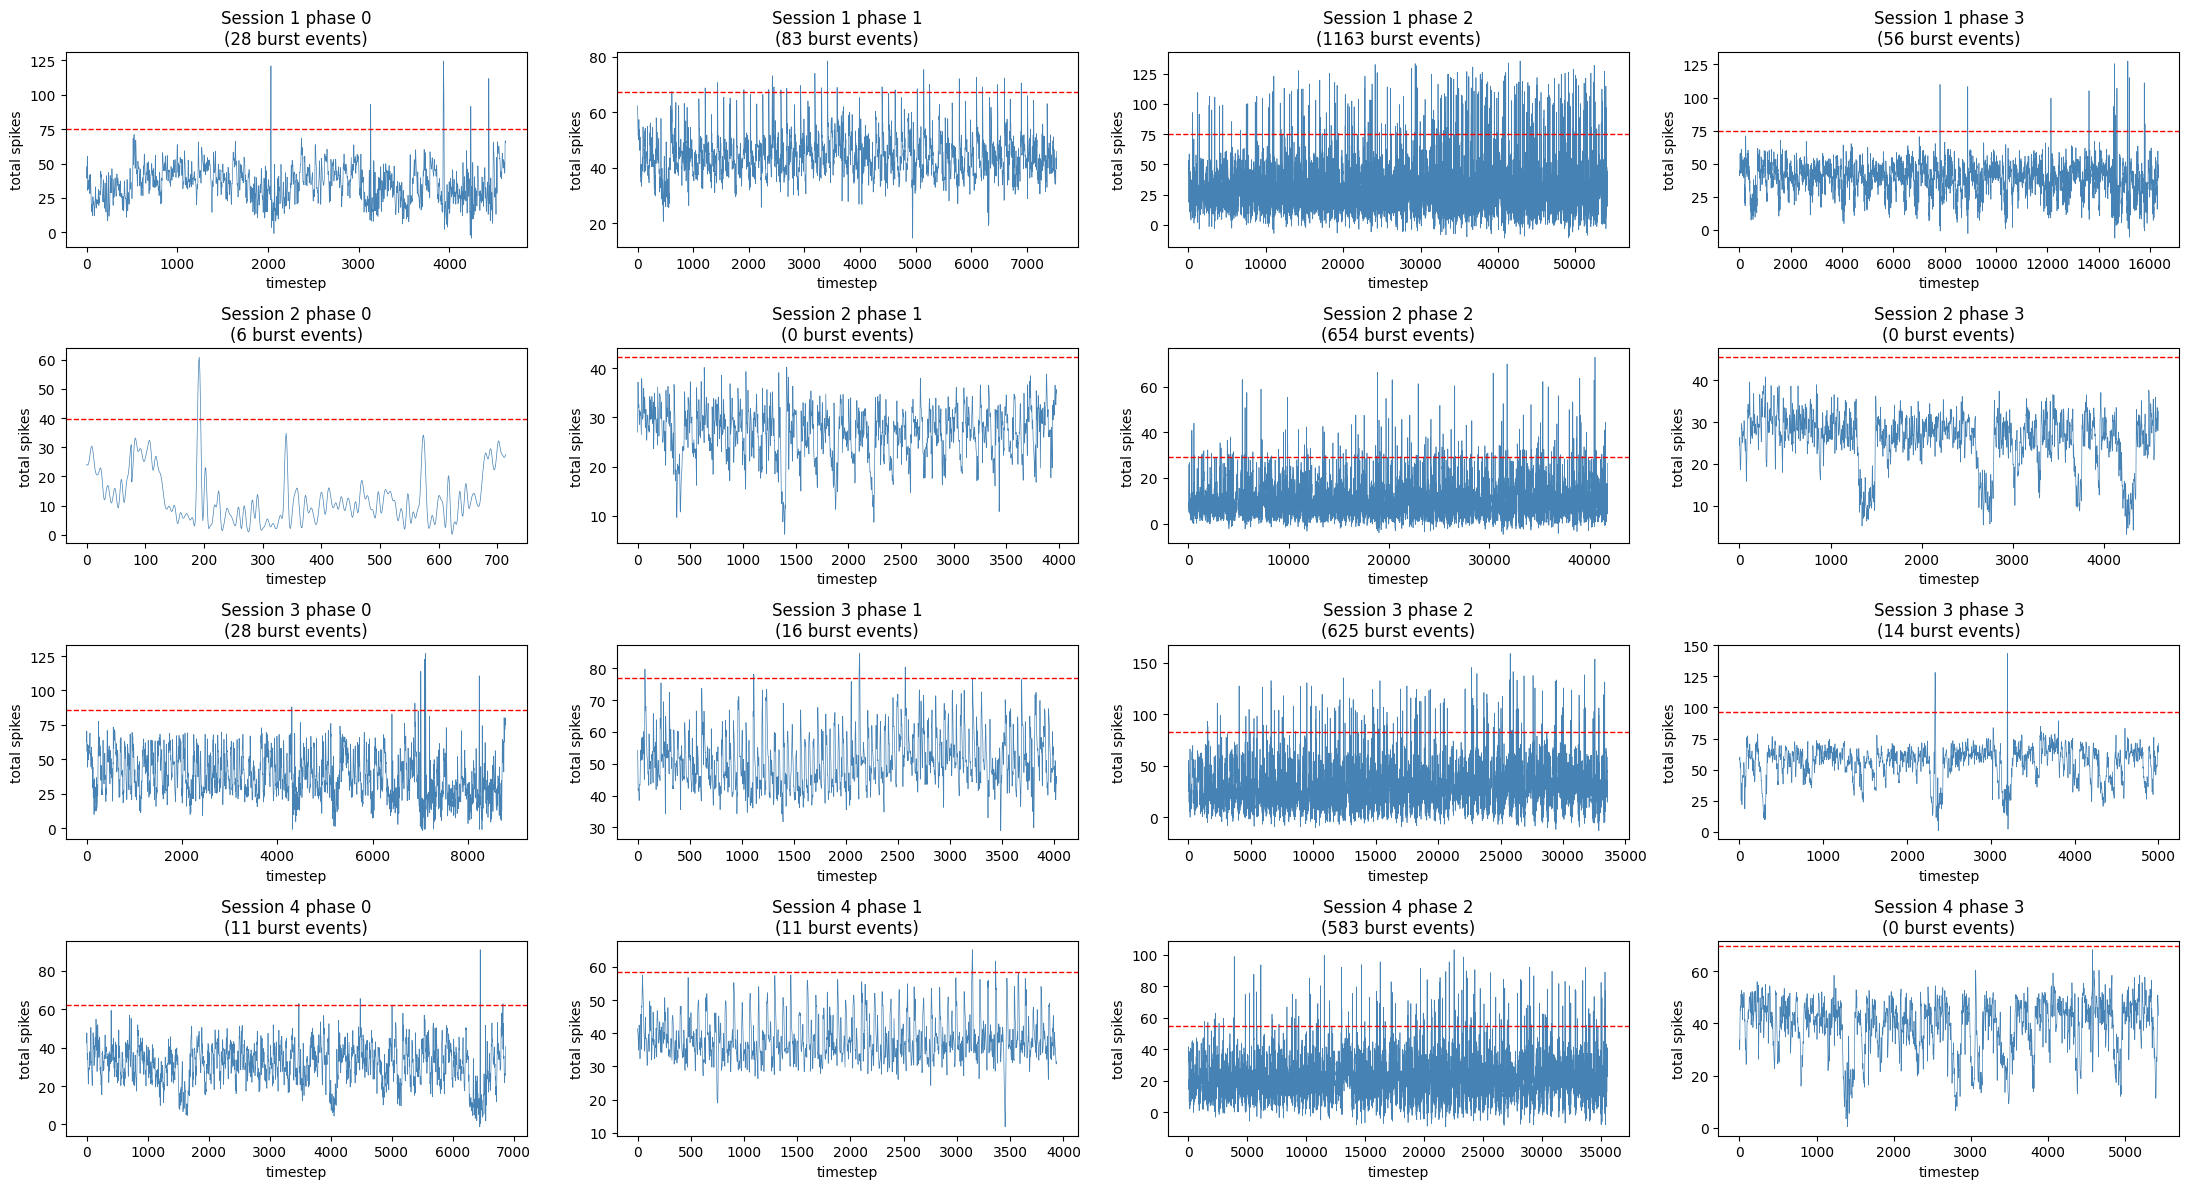

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/replay_event/processed-rat-data/"

# phase mapping matches COL_PHASE from data_processing.ipynb:
# 0=other, 1=running towards port, 2=at reward port, 3=running away from port
PHASE_NAMES = {0: "other",
               1: "running towards port",
               2: "at reward port",
               3: "running away from port"}

fig, axes = plt.subplots(4, 4, figsize=(22, 12))  # now 4 columns for 4 phases

for i in range(1, 5):
    fname = f"{DATA_PATH}/spDat{i}0.mat"
    dat = sio.loadmat(fname)
    X = dat['X']
    lapID = dat['lapID']
    phase_col = lapID[:, 4]

    for phase in range(4):
        phase_mask = phase_col == phase
        X_phase = X[phase_mask]

        ax = axes[i-1, phase]

        pop_activity = X_phase.sum(axis=1)
        mean = pop_activity.mean()
        std  = pop_activity.std()
        threshold = mean + 3 * std
        burst_mask = pop_activity > threshold

        ax.plot(pop_activity, lw=0.5, color='steelblue')
        ax.axhline(threshold, color='red', lw=1, linestyle='--', label=f'threshold ({THRESHOLD_STD}σ)')
        #ax.fill_between(np.arange(len(pop_activity)), 0, pop_activity,where=burst_mask, color='red', alpha=0.4)
        ax.set_title(f"Session {i} phase {phase}\n"
                     f"({burst_mask.sum()} burst events)")
        ax.set_xlabel("timestep")
        ax.set_ylabel("total spikes")

plt.tight_layout()
#plt.savefig(f"/content/drive/MyDrive/replay_event/detect-replay-events/population_burst_overview.png", dpi=150)
plt.show()

In [ ]:
take median error take abs value of it
timestep difference
go with phase 0
difference between start and end
4 time period (4 phases)
diff in time;ripple activity;diff drift


SyntaxError: invalid syntax (1011366081.py, line 1)

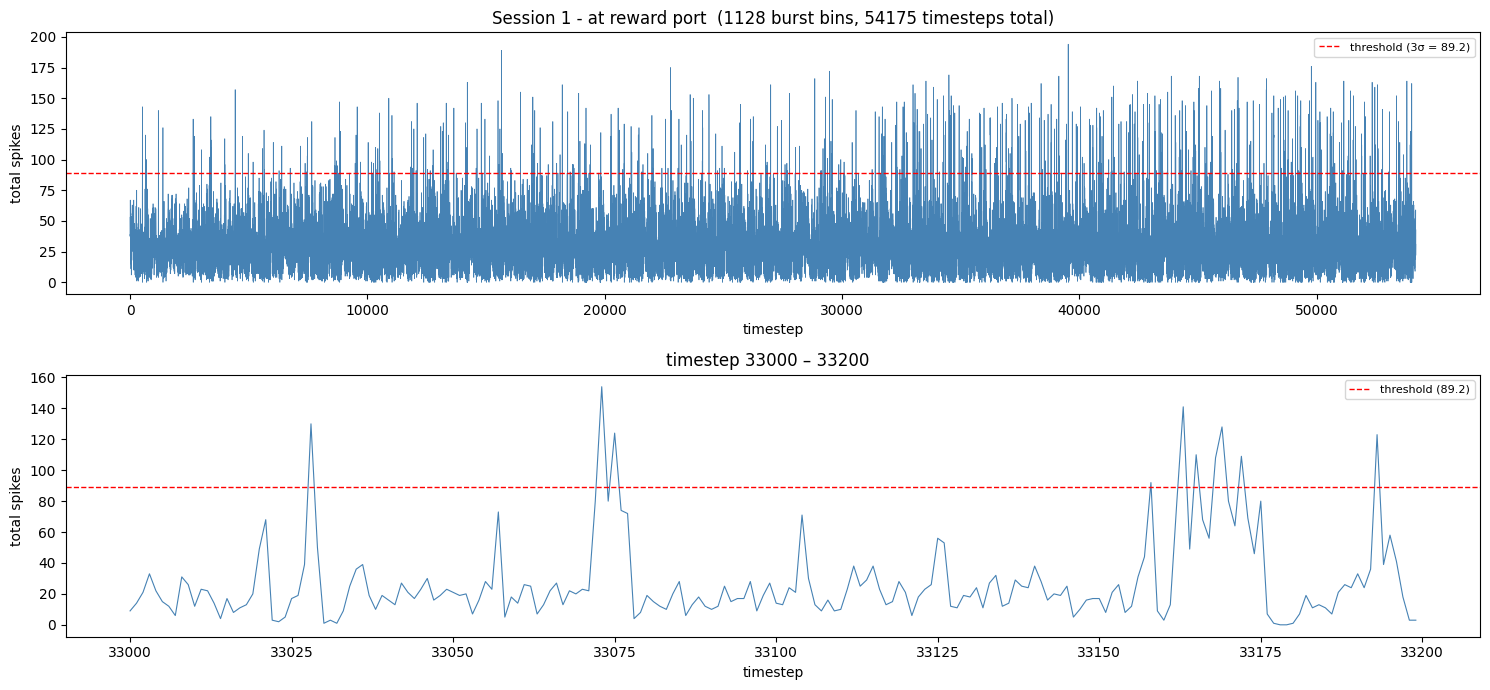

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

SESSION = 1
PHASE   = 1
T_START = 33000
T_END   = 33200

SAVE_PATH      = "/content/drive/MyDrive/replay_event/processed-rat-data/spDat"
PHASE_NAMES    = {0: "running towards port",
                  1: "at reward port",
                  2: "running away from port"}

fname = f"{SAVE_PATH}/spDat{SESSION}{PHASE}.mat"
dat   = sio.loadmat(fname)
pop_activity = dat['X'].sum(axis=1)
total_len = len(pop_activity)
mean = pop_activity.mean()
std = pop_activity.std()
threshold = mean + 3 * std
burst_mask = pop_activity > threshold

t_start = max(0, T_START)
t_end  = min(total_len, T_END)

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

# full view
ax = axes[0]
ax.plot(pop_activity, lw=0.5, color='steelblue')
ax.axhline(threshold, color='red', lw=1, linestyle='--',
           label=f'threshold ({THRESHOLD_STD}σ = {threshold:.1f})')
#ax.fill_between(np.arange(total_len), 0, pop_activity, where=burst_mask, color='red', alpha=0.4)
ax.set_title(f"Session {SESSION} - {PHASE_NAMES[PHASE]}  "
             f"({burst_mask.sum()} burst bins, {total_len} timesteps total)")
ax.set_xlabel("timestep")
ax.set_ylabel("total spikes")
ax.legend(fontsize=8)

# zoomed view
t_axis     = np.arange(t_start, t_end)
zoomed     = pop_activity[t_start:t_end]

ax2 = axes[1]
ax2.plot(t_axis, zoomed, lw=0.8, color='steelblue')
ax2.axhline(threshold, color='red', lw=1, linestyle='--',
            label=f'threshold ({threshold:.1f})')
ax2.set_title(f"timestep {t_start} – {t_end}  ")
ax2.set_xlabel("timestep")
ax2.set_ylabel("total spikes")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import scipy.io as sio
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/replay_event/processed-rat-data/"
N_SESSIONS = 4

all_rows = []

for i in range(1, N_SESSIONS + 1):
    fname = f"{DATA_PATH}/spDat{i}_rp.mat"
    dat = sio.loadmat(fname)

    X = dat['X']  # (n_timesteps, n_neurons)
    lapID  = dat['lapID']  # col0=trial, col1=cv_fold, col2=virtual_arm, col3=orig_idx, col4=phase

    trial_col = lapID[:, 0]
    phase_col = lapID[:, 4]

    # population activity threshold computed globally per session
    # (same baseline as your burst detection code)
    pop_activity = X.sum(axis=1)
    mean_global  = pop_activity.mean()
    std_global   = pop_activity.std()
    threshold    = mean_global + 3 * std_global
    burst_mask   = pop_activity > threshold

    trials = np.unique(trial_col).astype(int)

    for trial in trials:
        for phase in range(4):  # 0=other, 1=towards, 2=at port, 3=away
            mask = (trial_col == trial) & (phase_col == phase)
            if not np.any(mask):
                continue

            n_timesteps   = int(np.sum(mask))
            n_ripples = int(np.sum(burst_mask[mask]))

            all_rows.append({
                'session': i,
                'trial': trial,
                'phase':  phase,
                'n_timesteps': n_timesteps,
                'n_ripples':  n_ripples,
            })

df = pd.DataFrame(all_rows)
print(df.head(20))
print(f"\ntotal rows: {len(df)}")

save_path = "/content/drive/MyDrive/replay_event/processed-rat-data/matrix_ripple_only.mat"
sio.savemat(save_path, {
    'session': df['session'].to_numpy().astype(np.int32),
    'trial': df['trial'].to_numpy().astype(np.int32),
    'phase': df['phase'].to_numpy().astype(np.int32),
    'n_timesteps': df['n_timesteps'].to_numpy().astype(np.int32),
    'n_ripples': df['n_ripples'].to_numpy().astype(np.int32),
})
print(f"saved {save_path}")

    session  trial  phase  n_timesteps  n_ripples
0         1      0      0         1964          0
1         1      0      1           49          0
2         1      0      2           95          0
3         1      0      3           57          0
4         1      1      0          539          0
5         1      1      1           44          0
6         1      1      2          876          2
7         1      1      3           47          0
8         1      2      0          737          0
9         1      2      1           44          0
10        1      2      2           90          0
11        1      2      3           56          0
12        1      3      0          499          0
13        1      3      1           46          0
14        1      3      2          555          7
15        1      3      3          108          0
16        1      4      0          406          0
17        1      4      1           44          0
18        1      4      2          164          0
